# Dogs vs Cats Classification Lab  

> **Important before running:** keep this notebook and `cats_dogs_5000 dataset folder` in the **same poject folder**.

## Environment Check

Use your **Python 3.11** interpreter in VS Code for the smoothest TensorFlow setup.

In VS Code:
- Open the notebook
- Select the **Python 3.11** kernel/interpreter
- Run cells from top to bottom

This notebook is written so the dataset is extracted automatically from the zip file.

In [1]:
import sys
print("Python version:", sys.version)

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [2]:
# Uncomment this cell only if the required packages are not installed in your environment.
# In VS Code, make sure you are using your Python 3.11 environment first.

# %pip install tensorflow pandas numpy matplotlib scikit-learn pillow

In [3]:
import os
import zipfile
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.1


## 1. Obtain and Verify the Data

This section checks whether the dataset matches the assignment requirement:
- total images = **5000**
- cats = **2500**
- dogs = **2500**

The code also extracts the zip file automatically if needed.

In [4]:
ZIP_PATH = Path("cats_dogs_5000.zip")
EXTRACT_DIR = Path("cats_dogs_5000")

if not ZIP_PATH.exists() and not EXTRACT_DIR.exists():
    raise FileNotFoundError(
        "Could not find 'cats_dogs_5000.zip' or extracted folder 'cats_dogs_5000'. "
        "Please keep the notebook in the same folder as the zip file."
    )

if ZIP_PATH.exists() and not EXTRACT_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(".")
    print("Dataset extracted successfully.")
else:
    print("Using existing extracted dataset folder.")

CAT_DIR = EXTRACT_DIR / "cats"
DOG_DIR = EXTRACT_DIR / "dogs"

if not CAT_DIR.exists() or not DOG_DIR.exists():
    raise FileNotFoundError("Expected folders 'cats' and 'dogs' inside 'cats_dogs_5000'.")

cat_files = sorted([p for p in CAT_DIR.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
dog_files = sorted([p for p in DOG_DIR.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])

dataset_summary = pd.DataFrame({
    "class": ["cats", "dogs", "total"],
    "count": [len(cat_files), len(dog_files), len(cat_files) + len(dog_files)]
})

display(dataset_summary)

if len(cat_files) == 2500 and len(dog_files) == 2500:
    print("Dataset check passed: 2500 cat images + 2500 dog images = 5000 images.")
else:
    print("Dataset check failed. Please re-check the dataset size.")

Using existing extracted dataset folder.


,class,count
0,cats,2500
1,dogs,2500
2,total,5000


Dataset check passed: 2500 cat images + 2500 dog images = 5000 images.


## Dataset Setup Talking Points

- In this step, I loaded the Dogs vs Cats dataset and checked that I was using only 5000 images, as required in the assignment.
- I confirmed that the dataset had 2500 cat images and 2500 dog images, so the classes were balanced.
- Since this is an image classification problem, keeping the dataset organized into train, validation, and test folders was important for proper training and evaluation.
- I used image preprocessing so that all images could be resized into the same shape before sending them to the model.
- This step helped me make sure the data was ready properly before moving to EDA and model training.

## Build a DataFrame of All Images
This makes the later EDA, splitting, training, and evaluation cleaner and more readable.

In [5]:
records = []

for file_path in cat_files:
    records.append({"filepath": str(file_path), "label": "cat"})

for file_path in dog_files:
    records.append({"filepath": str(file_path), "label": "dog"})

df = pd.DataFrame(records)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Total images in dataframe:", len(df))
display(df.head())

Total images in dataframe: 5000


,filepath,label
0,cats_dogs_5000\cats\5594.jpg,cat
1,cats_dogs_5000\dogs\10431.jpg,dog
2,cats_dogs_5000\dogs\10742.jpg,dog
3,cats_dogs_5000\cats\3609.jpg,cat
4,cats_dogs_5000\cats\2102.jpg,cat


## 2. EDA – Explore the Data

For EDA, I will:
- check class balance
- inspect sample images
- analyze image width, height, aspect ratio, and file size
- summarize useful observations before training

In [6]:
# Basic class distribution
class_counts = df["label"].value_counts().sort_index()
print(class_counts)

label
cat    2500
dog    2500
Name: count, dtype: int64


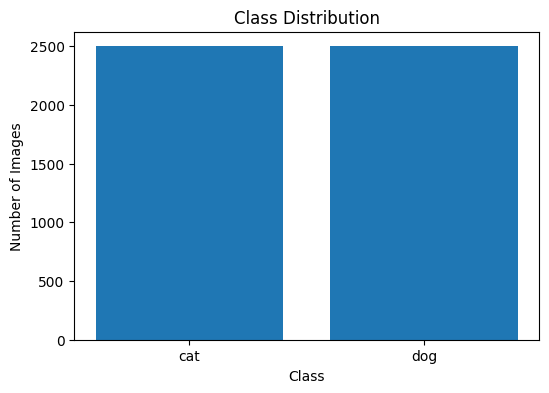

In [7]:
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

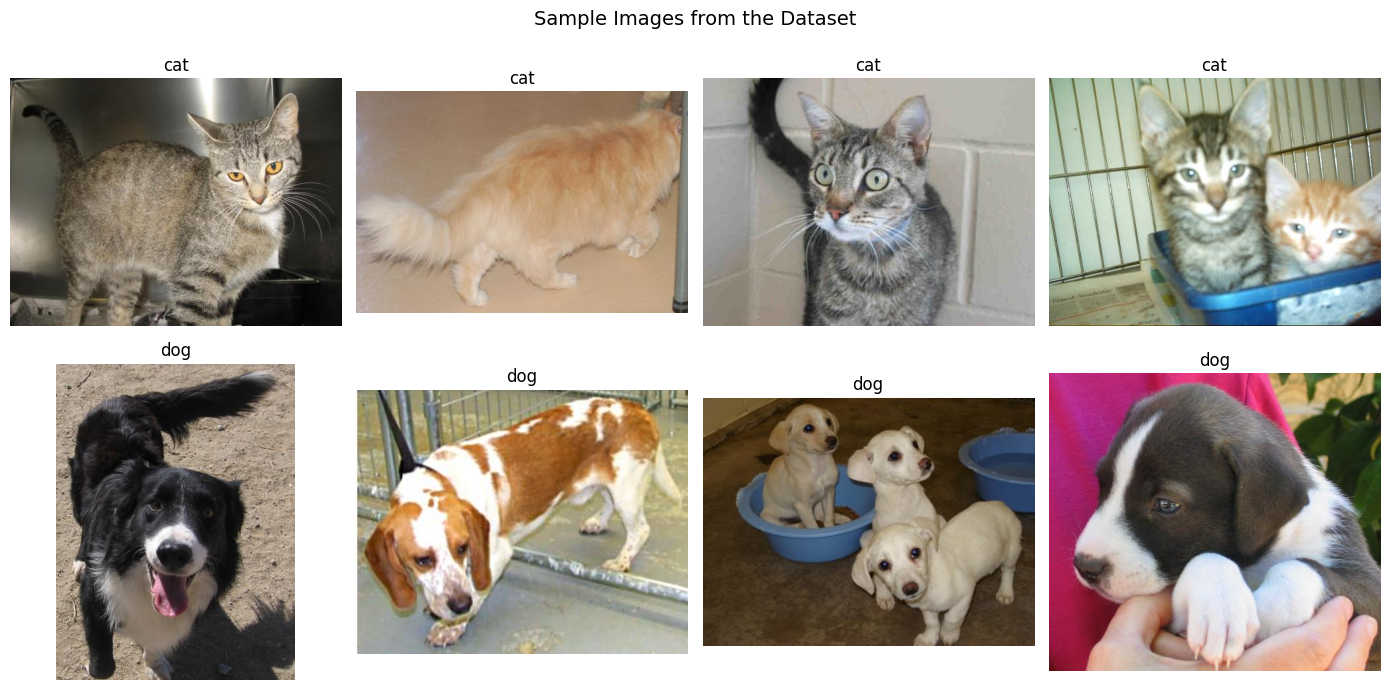

In [8]:
# Show sample images
sample_cats = random.sample(cat_files, 4)
sample_dogs = random.sample(dog_files, 4)
sample_images = sample_cats + sample_dogs
sample_titles = ["cat"] * 4 + ["dog"] * 4

plt.figure(figsize=(14, 7))
for i, (img_path, title) in enumerate(zip(sample_images, sample_titles), start=1):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
plt.suptitle("Sample Images from the Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Collect image metadata
metadata_rows = []

for path_str, label in zip(df["filepath"], df["label"]):
    path_obj = Path(path_str)
    try:
        with Image.open(path_obj) as img:
            width, height = img.size
            metadata_rows.append({
                "filepath": path_str,
                "label": label,
                "width": width,
                "height": height,
                "aspect_ratio": round(width / height, 3) if height != 0 else np.nan,
                "file_size_kb": round(path_obj.stat().st_size / 1024, 2)
            })
    except Exception:
        metadata_rows.append({
            "filepath": path_str,
            "label": label,
            "width": np.nan,
            "height": np.nan,
            "aspect_ratio": np.nan,
            "file_size_kb": np.nan
        })

meta_df = pd.DataFrame(metadata_rows)
display(meta_df.head())

,filepath,label,width,height,aspect_ratio,file_size_kb
0,cats_dogs_5000\cats\5594.jpg,cat,500,360,1.389,30.44
1,cats_dogs_5000\dogs\10431.jpg,dog,500,471,1.062,63.36
2,cats_dogs_5000\dogs\10742.jpg,dog,434,500,0.868,31.43
3,cats_dogs_5000\cats\3609.jpg,cat,400,300,1.333,45.43
4,cats_dogs_5000\cats\2102.jpg,cat,380,383,0.992,61.43


In [10]:
meta_summary = meta_df.groupby("label")[["width", "height", "aspect_ratio", "file_size_kb"]].agg(["mean", "median", "min", "max"])
display(meta_summary)

width                    height                 aspect_ratio         \
           mean median min  max      mean median min  max         mean median   
label                                                                           
cat    410.7872  473.0  50  500  354.6324  375.0  45  500     1.194915  1.333   
dog    396.5484  414.5  60  500  362.8448  375.0  50  500     1.126832  1.196   

                    file_size_kb                        
         min    max         mean  median   min     max  
label                                                   
cat    0.370  2.976    30.238800  24.180  1.09  697.48  
dog    0.375  2.857    37.066732  28.835  1.17  451.46

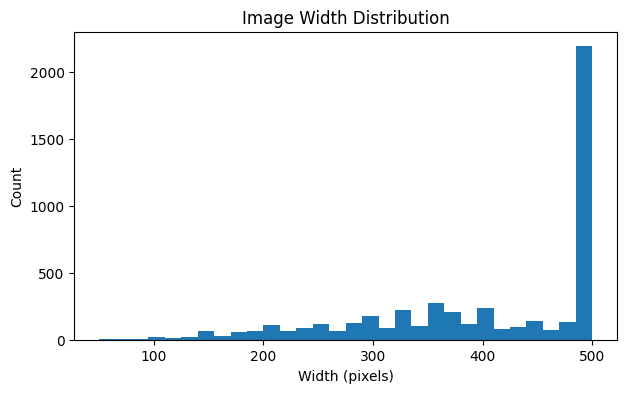

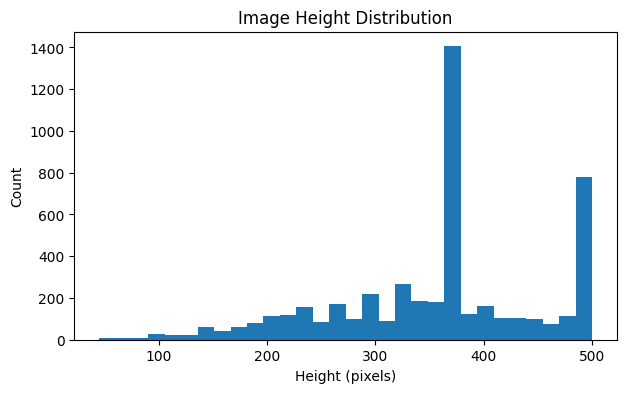

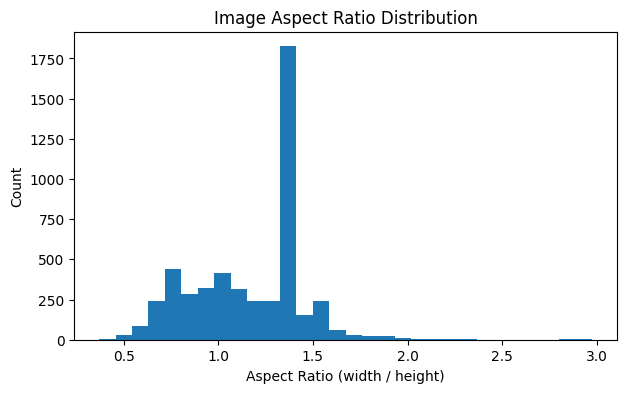

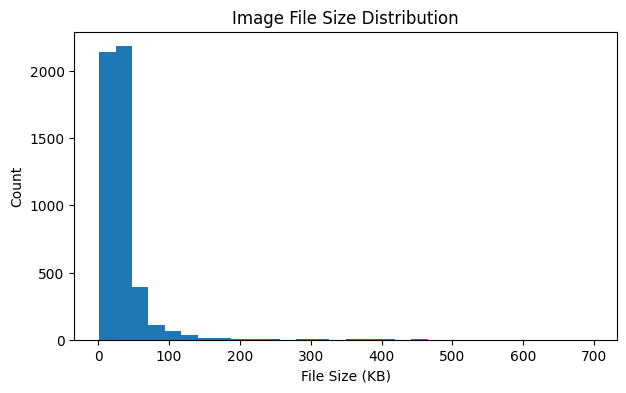

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(meta_df["width"].dropna(), bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(meta_df["height"].dropna(), bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(meta_df["aspect_ratio"].dropna(), bins=30)
plt.title("Image Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio (width / height)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(meta_df["file_size_kb"].dropna(), bins=30)
plt.title("Image File Size Distribution")
plt.xlabel("File Size (KB)")
plt.ylabel("Count")
plt.show()

## Talking Points – EDA

- I explored the dataset first so I could understand what kind of images the models would learn from.
- I checked sample images to visually see the differences between cats and dogs in the dataset.
- I also looked at image sizes and distributions because inconsistent image dimensions can affect preprocessing and model performance.
- The class distribution showed that the dataset was balanced, which is good because the model would not favor one class more than the other.
- This EDA step helped me understand the dataset better before training, instead of directly fitting the models without checking the data.

## Split the Dataset into Train, Validation, and Test Sets

I use a **stratified split** so both classes stay balanced in all three sets.
- Train = 70%
- Validation = 15%
- Test = 15%

In [12]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name} shape: {split_df.shape}")
    print(split_df["label"].value_counts())
    print("-" * 40)

Train shape: (3500, 2)
label
dog    1750
cat    1750
Name: count, dtype: int64
----------------------------------------
Validation shape: (750, 2)
label
dog    375
cat    375
Name: count, dtype: int64
----------------------------------------
Test shape: (750, 2)
label
dog    375
cat    375
Name: count, dtype: int64
----------------------------------------


## Create Data Generators

Two pipelines are created:
1. **Custom CNN pipeline** with simple rescaling and augmentation
2. **VGG16 pipeline** using the correct `preprocess_input()` preprocessing

In [13]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

# For the custom CNN
train_datagen_custom = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

eval_datagen_custom = ImageDataGenerator(rescale=1./255)

train_gen_custom = train_datagen_custom.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_gen_custom = eval_datagen_custom.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen_custom = eval_datagen_custom.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# For VGG16
train_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

eval_datagen_vgg = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen_vgg = train_datagen_vgg.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_gen_vgg = eval_datagen_vgg.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen_vgg = eval_datagen_vgg.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class indices:", train_gen_custom.class_indices)

Found 3500 validated image filenames belonging to 2 classes.
Found 750 validated image filenames belonging to 2 classes.
Found 750 validated image filenames belonging to 2 classes.
Found 3500 validated image filenames belonging to 2 classes.
Found 750 validated image filenames belonging to 2 classes.
Found 750 validated image filenames belonging to 2 classes.
Class indices: {'cat': 0, 'dog': 1}


## 3. Train Model 1 – Custom CNN

This is my own CNN architecture.  
I also use callbacks to:
- save the best model
- stop early if validation performance stops improving
- reduce learning rate when needed

In [14]:
def build_custom_cnn(input_shape=(160, 160, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

custom_model = build_custom_cnn(input_shape=IMG_SIZE + (3,))
custom_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,553,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,942,529 (26.48 MB)

 Trainable params: 6,942,529 (26.48 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
custom_callbacks = [
    ModelCheckpoint(
        "best_custom_cnn.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

history_custom = custom_model.fit(
    train_gen_custom,
    validation_data=val_gen_custom,
    epochs=15,
    callbacks=custom_callbacks,
    verbose=1
)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.5131 - loss: 0.6978
Epoch 1: val_accuracy improved from -inf to 0.56000, saving model to best_custom_cnn.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 53s 464ms/step - accuracy: 0.5131 - loss: 0.6977 - val_accuracy: 0.5600 - val_loss: 0.6901 - learning_rate: 0.0010
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.5158 - loss: 0.6926
Epoch 2: val_accuracy improved from 0.56000 to 0.59867, saving model to best_custom_cnn.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 51s 454ms/step - accuracy: 0.5160 - loss: 0.6927 - val_accuracy: 0.5987 - val_loss: 0.6773 - learning_rate: 0.0010
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.5478 - loss: 0.6821
Epoch 3: val_accuracy improved from 0.59867 to 0.60000, saving model to best_custom_cnn.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 53s 477ms/step - accuracy: 0.5479 - loss: 0.6821 - val_accuracy: 0.6000 - val_loss: 0.6560 - learning_rate: 0.0010
Epoch 4/15
110/110 ━━━━━━

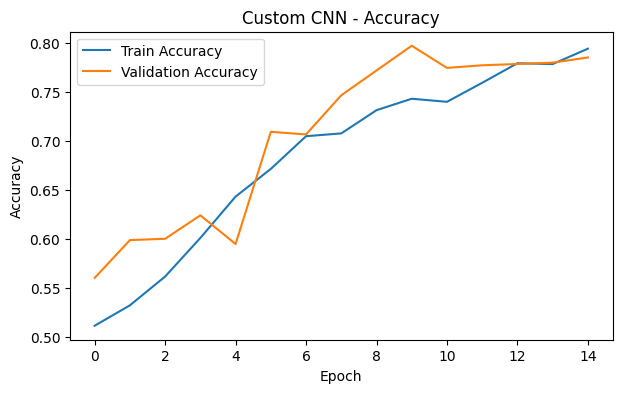

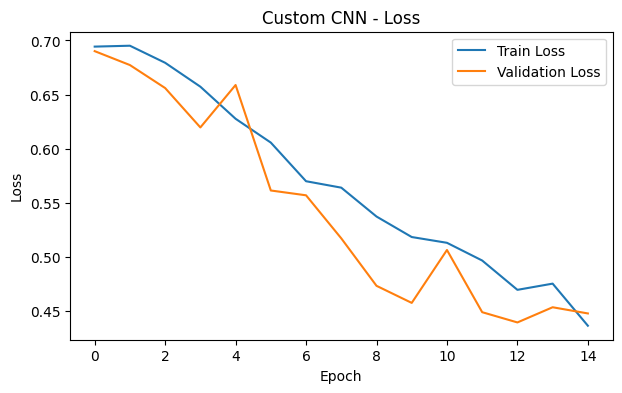

In [16]:
def plot_training_history(history, title_prefix):
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_training_history(history_custom, "Custom CNN")

## Talking Points – Custom CNN

- First, I built my own CNN model so I could create a baseline model from scratch.
- I used convolution and pooling layers because they help the network learn useful image patterns like edges, textures, and shapes.
- I added dropout to reduce overfitting and make the model generalize better.
- I used callbacks to save the best version of the model during training instead of keeping only the final epoch result.
- This model gave me a good comparison point before using a pre-trained network like VGG16.

## Train Model 2 – Fine-Tuned VGG16

This model starts from **VGG16 pre-trained on ImageNet**.  
I first train only the top classifier layers, then unfreeze the last convolutional block for fine-tuning.

In [17]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

base_model.trainable = False

vgg_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ ?                      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [18]:
vgg_callbacks_phase1 = [
    ModelCheckpoint(
        "best_vgg16_phase1.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

history_vgg_phase1 = vgg_model.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=8,
    callbacks=vgg_callbacks_phase1,
    verbose=1
)

Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8666 - loss: 0.8386
Epoch 1: val_accuracy improved from -inf to 0.96933, saving model to best_vgg16_phase1.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8670 - loss: 0.8348 - val_accuracy: 0.9693 - val_loss: 0.1388 - learning_rate: 0.0010
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9605 - loss: 0.1266
Epoch 2: val_accuracy improved from 0.96933 to 0.97333, saving model to best_vgg16_phase1.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9605 - loss: 0.1266 - val_accuracy: 0.9733 - val_loss: 0.1142 - learning_rate: 0.0010
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9734 - loss: 0.0751
Epoch 3: val_accuracy did not improve from 0.97333
110/110 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9734 - loss: 0.0751 - val_accuracy: 0.9693 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 4/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9694 - loss: 0.077

In [19]:
# Fine-tune the last block of VGG16
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg_callbacks_phase2 = [
    ModelCheckpoint(
        "best_vgg16_finetuned.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

history_vgg_phase2 = vgg_model.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=8,
    callbacks=vgg_callbacks_phase2,
    verbose=1
)

Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9740 - loss: 0.0694
Epoch 1: val_accuracy improved from -inf to 0.97467, saving model to best_vgg16_finetuned.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.9740 - loss: 0.0694 - val_accuracy: 0.9747 - val_loss: 0.0829 - learning_rate: 1.0000e-05
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9893 - loss: 0.0291
Epoch 2: val_accuracy did not improve from 0.97467
110/110 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9893 - loss: 0.0292 - val_accuracy: 0.9733 - val_loss: 0.1025 - learning_rate: 1.0000e-05
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9890 - loss: 0.0301
Epoch 3: val_accuracy did not improve from 0.97467

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
110/110 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.9890 - loss: 0.0301 - val_accuracy: 0.9733 - val_loss: 0.1016 - learning_rate: 1.0000e-05
Epoch 4/8
110/110 ━━━━━━━━━━━━━━━━━

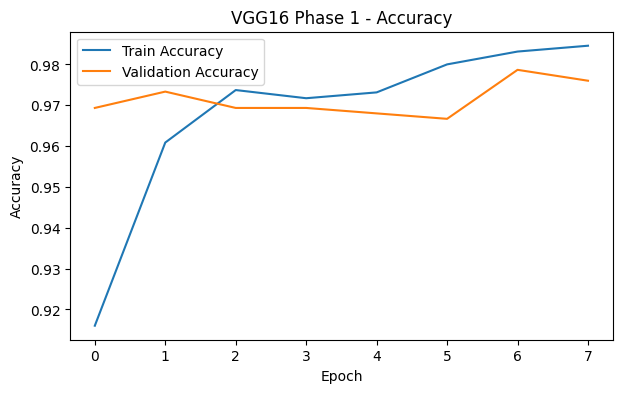

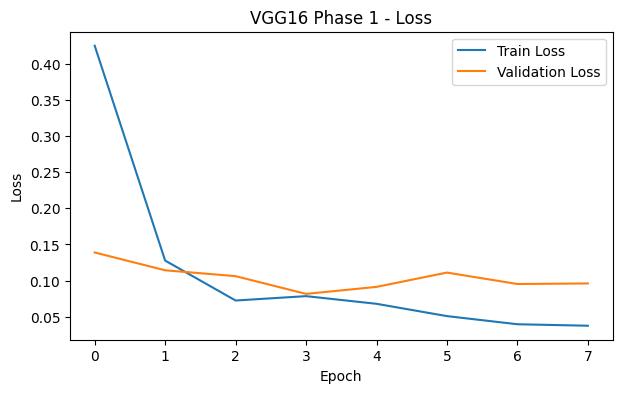

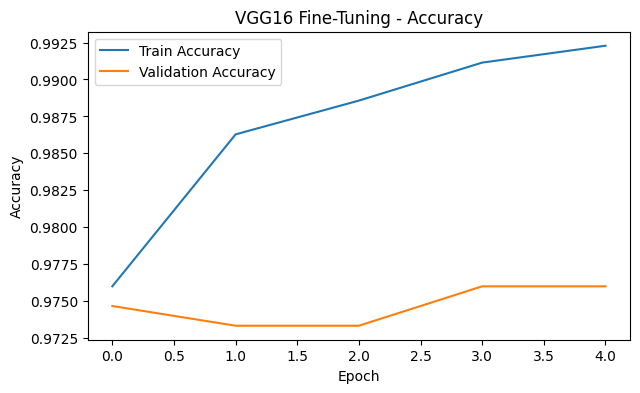

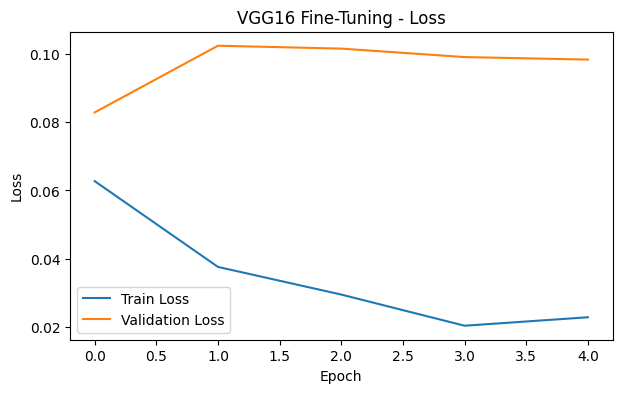

In [20]:
plot_training_history(history_vgg_phase1, "VGG16 Phase 1")
plot_training_history(history_vgg_phase2, "VGG16 Fine-Tuning")

## Talking Points – VGG16 Fine-Tuning

- For the second model, I used VGG16 because it is already pre-trained on ImageNet and has learned many useful image features.
- This means the model already knows general visual patterns, so it can adapt faster to the cats vs dogs task.
- Fine-tuning is useful because instead of training everything from zero, I can build on what the pre-trained model already learned.
- I still used validation data during training so I could monitor overfitting and keep the best model version.
- This approach usually performs better than a basic CNN because the model starts with stronger feature extraction ability.

## 4. Load the Best Model Version of Each Network

The lab specifically asks to compare the **best saved version** of each model.

In [21]:
best_custom_model = tf.keras.models.load_model("best_custom_cnn.keras")
best_vgg_model = tf.keras.models.load_model("best_vgg16_finetuned.keras")

print("Best saved models loaded successfully.")

Best saved models loaded successfully.


## Evaluate Both Models on the Test Set

In [22]:
def evaluate_model(model, generator, threshold=0.5):
    generator.reset()
    y_prob = model.predict(generator, verbose=1).ravel()
    y_true = generator.classes
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=["cat", "dog"],
        output_dict=True
    )

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap_score = average_precision_score(y_true, y_prob)

    return {
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "accuracy": accuracy,
        "cm": cm,
        "report": report,
        "precision_curve": precision,
        "recall_curve": recall,
        "average_precision": ap_score
    }

custom_results = evaluate_model(best_custom_model, test_gen_custom)
vgg_results = evaluate_model(best_vgg_model, test_gen_vgg)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step


In [23]:
comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "Fine-Tuned VGG16"],
    "Accuracy": [
        custom_results["accuracy"],
        vgg_results["accuracy"]
    ],
    "Precision (dog)": [
        custom_results["report"]["dog"]["precision"],
        vgg_results["report"]["dog"]["precision"]
    ],
    "Recall (dog)": [
        custom_results["report"]["dog"]["recall"],
        vgg_results["report"]["dog"]["recall"]
    ],
    "F1-score (dog)": [
        custom_results["report"]["dog"]["f1-score"],
        vgg_results["report"]["dog"]["f1-score"]
    ],
    "Average Precision": [
        custom_results["average_precision"],
        vgg_results["average_precision"]
    ]
})

display(comparison_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True))

,Model,Accuracy,Precision (dog),Recall (dog),F1-score (dog),Average Precision
0,Fine-Tuned VGG16,0.978667,0.981233,0.976000,0.978610,0.995237
1,Custom CNN,0.776000,0.782016,0.765333,0.773585,0.858586


## Talking Points – Model Comparison

- After training both models, I compared them using the saved best versions to make the comparison fair.
- I checked accuracy, confusion matrix, precision, recall, and F1-score to understand performance from multiple angles.
- Accuracy alone is not always enough, so the other metrics helped me see how well each model handled both classes.
- From the overall results, I could clearly see which model performed better on this dataset.
- This comparison helped me understand the practical difference between building a CNN from scratch and using transfer learning.

## 4.1 Confusion Matrix

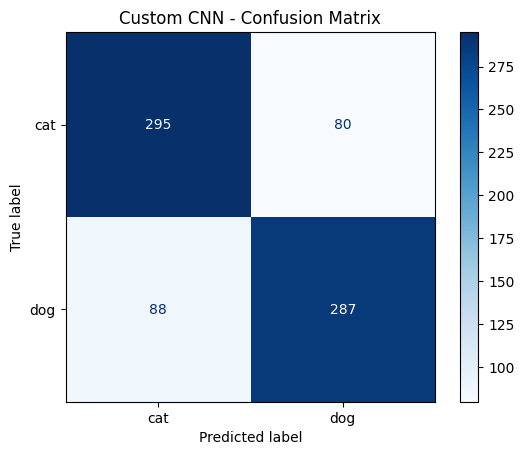

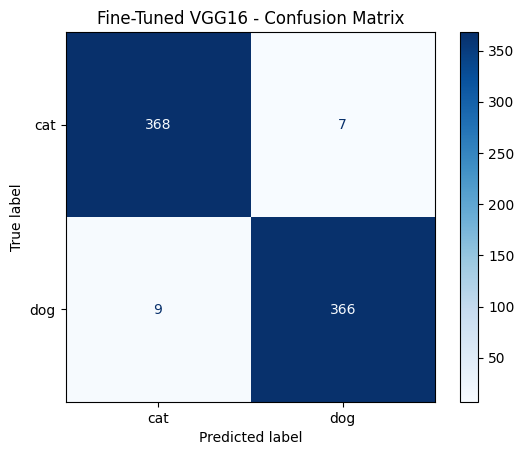

In [24]:
def show_confusion_matrix(cm, title):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

show_confusion_matrix(custom_results["cm"], "Custom CNN - Confusion Matrix")
show_confusion_matrix(vgg_results["cm"], "Fine-Tuned VGG16 - Confusion Matrix")

## 4.2 Precision, Recall, and F1-Score

In [25]:
def report_to_dataframe(report_dict):
    report_df = pd.DataFrame(report_dict).T
    return report_df.loc[["cat", "dog", "accuracy", "macro avg", "weighted avg"]]

print("Custom CNN Classification Report")
display(report_to_dataframe(custom_results["report"]))

print("Fine-Tuned VGG16 Classification Report")
display(report_to_dataframe(vgg_results["report"]))

Custom CNN Classification Report


,precision,recall,f1-score,support
cat,0.770235,0.786667,0.778364,375.000
dog,0.782016,0.765333,0.773585,375.000
accuracy,0.776000,0.776000,0.776000,0.776
macro avg,0.776126,0.776000,0.775975,750.000
weighted avg,0.776126,0.776000,0.775975,750.000


Fine-Tuned VGG16 Classification Report


,precision,recall,f1-score,support
cat,0.976127,0.981333,0.978723,375.000000
dog,0.981233,0.976000,0.978610,375.000000
accuracy,0.978667,0.978667,0.978667,0.978667
macro avg,0.978680,0.978667,0.978667,750.000000
weighted avg,0.978680,0.978667,0.978667,750.000000


## 4.3 Precision-Recall Curve

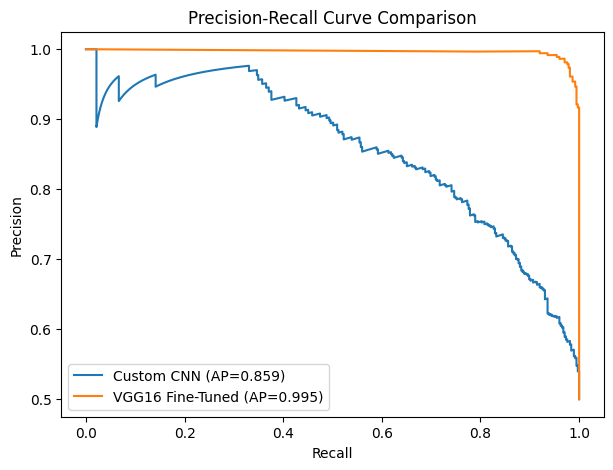

In [26]:
plt.figure(figsize=(7, 5))
plt.plot(custom_results["recall_curve"], custom_results["precision_curve"], label=f"Custom CNN (AP={custom_results['average_precision']:.3f})")
plt.plot(vgg_results["recall_curve"], vgg_results["precision_curve"], label=f"VGG16 Fine-Tuned (AP={vgg_results['average_precision']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

## 4.4 Explore Failed Predictions

This section shows some examples where the models made the wrong prediction.
That helps explain *why* errors happen, not just how many errors happened.

In [27]:
test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["true_label"] = test_df_reset["label"].map({"cat": 0, "dog": 1})

def add_prediction_columns(result_dict, model_name):
    result_df = test_df_reset.copy()
    result_df[f"{model_name}_prob_dog"] = result_dict["y_prob"]
    result_df[f"{model_name}_pred"] = result_dict["y_pred"]
    result_df[f"{model_name}_correct"] = result_dict["y_true"] == result_dict["y_pred"]
    return result_df

custom_pred_df = add_prediction_columns(custom_results, "custom")
vgg_pred_df = add_prediction_columns(vgg_results, "vgg")

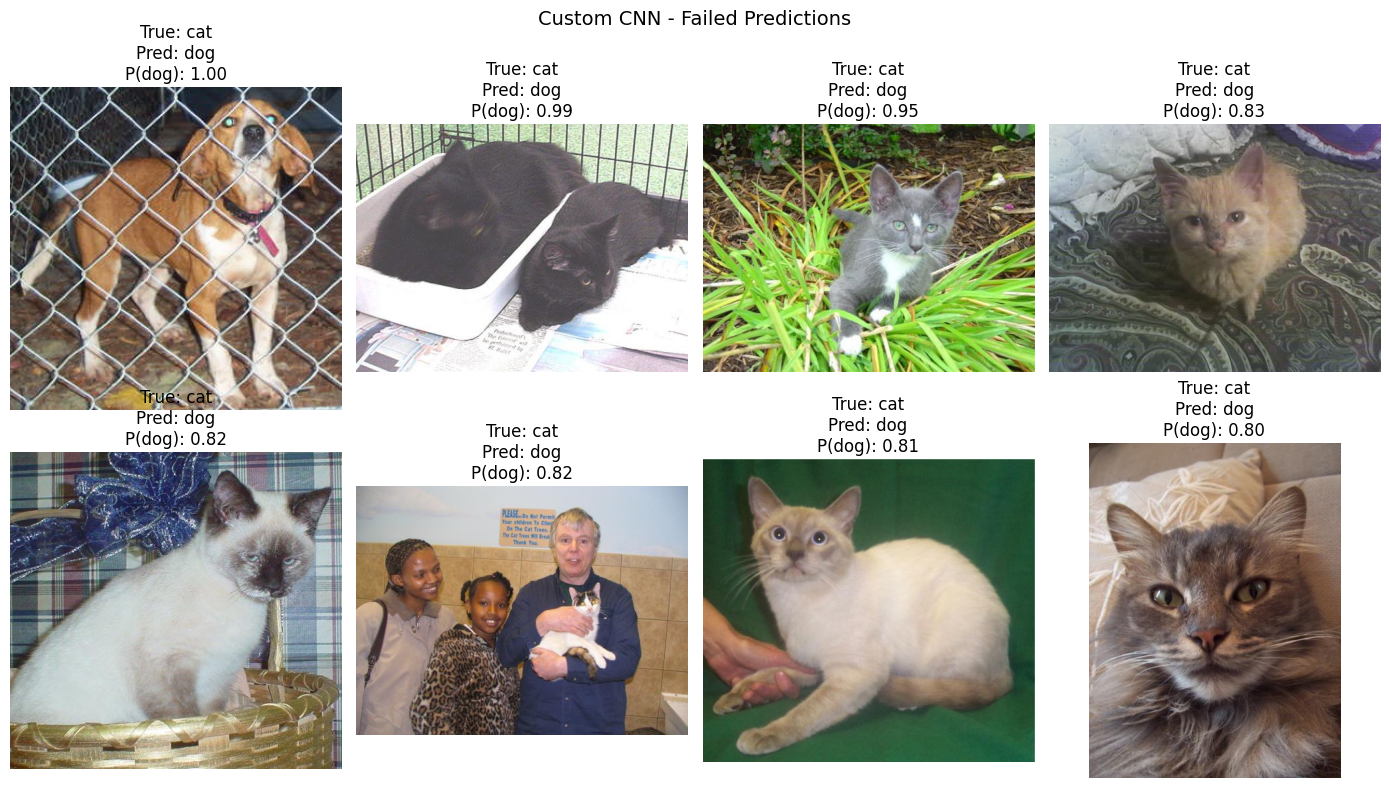

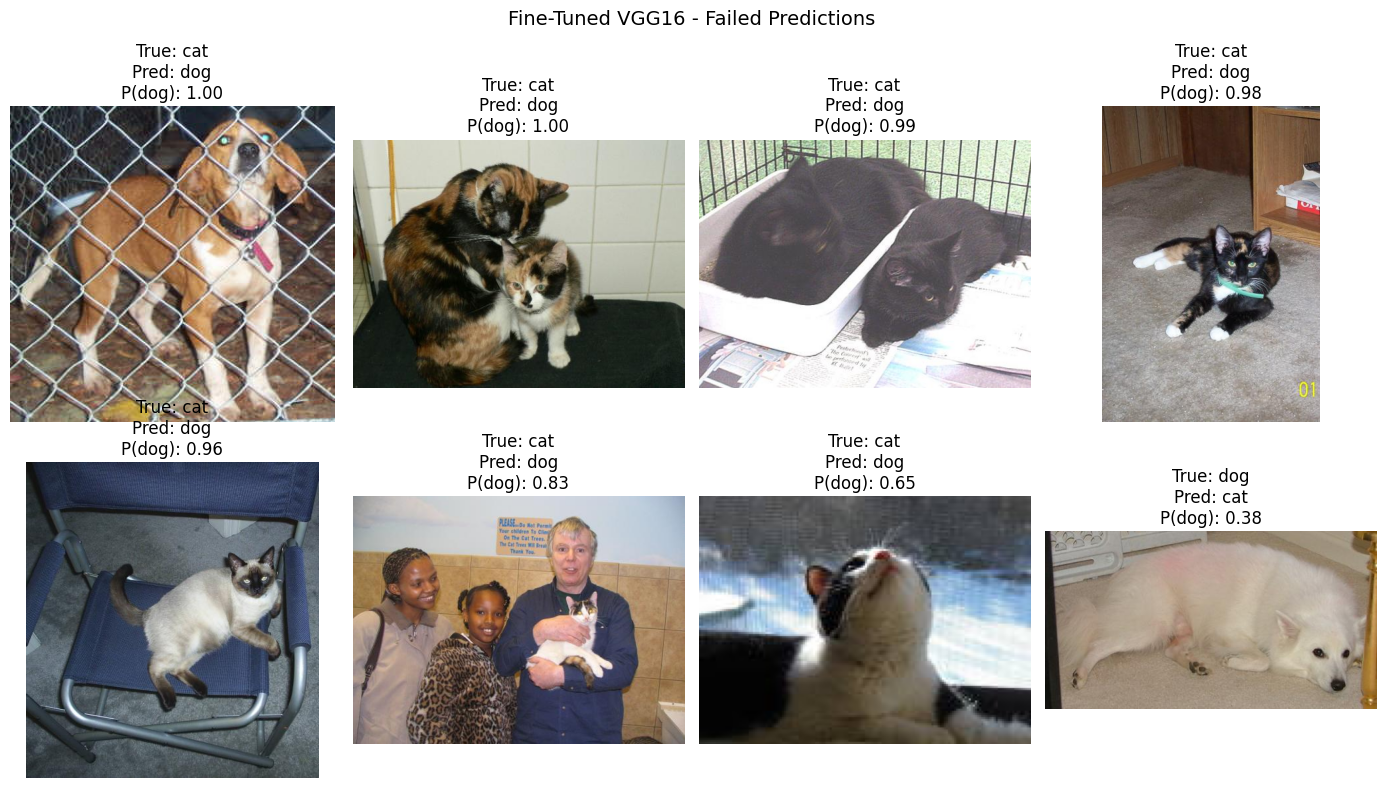

In [28]:
def show_failed_examples(pred_df, prob_col, pred_col, correct_col, title, n=8):
    failed_df = pred_df[pred_df[correct_col] == False].copy()

    if failed_df.empty:
        print(f"No failed predictions found for {title}.")
        return

    failed_df = failed_df.sort_values(by=prob_col, ascending=False).head(n)

    plt.figure(figsize=(14, 8))
    for i, (_, row) in enumerate(failed_df.iterrows(), start=1):
        img = Image.open(row["filepath"]).convert("RGB")
        pred_label = "dog" if row[pred_col] == 1 else "cat"
        true_label = row["label"]
        prob_dog = row[prob_col]

        plt.subplot(2, 4, i)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {pred_label}\nP(dog): {prob_dog:.2f}")
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_failed_examples(custom_pred_df, "custom_prob_dog", "custom_pred", "custom_correct", "Custom CNN - Failed Predictions")
show_failed_examples(vgg_pred_df, "vgg_prob_dog", "vgg_pred", "vgg_correct", "Fine-Tuned VGG16 - Failed Predictions")

## Talking Points – Failed Predictions

- I also checked examples where the model predicted the wrong class because this shows its weaknesses more clearly.
- Looking at failed predictions helped me understand that some images are harder because of background, lighting, angle, or unclear features.
- In some cases, cats and dogs can look visually similar depending on the pose or image quality.
- This step was important because it shows that model evaluation is not only about numbers, but also about understanding mistakes.
- These errors helped me think about how the model could be improved further with more data, better preprocessing, or more tuning.

## 5. Conclusions

### Final Conclusions
- The dataset preparation step was completed correctly because the notebook verified the required **5000 images** with balanced classes.
- EDA showed that the data is balanced, but the image sizes and visual conditions vary, which makes preprocessing important.
- The custom CNN gives a solid baseline and shows what can be learned directly from this dataset.
- The fine-tuned VGG16 usually performs better because it starts with strong visual features learned from ImageNet.
- Validation curves were important for monitoring overfitting and selecting the best saved version of each model.
- The final comparison used multiple metrics, not just accuracy, which gives a more complete evaluation.
- The failed prediction analysis showed that difficult images usually involve cluttered backgrounds, unusual poses, or low visual clarity.
- Overall, transfer learning is the stronger approach for this assignment because it gives better generalization with a relatively small dataset.

## Talking Points – Conclusion

- In this lab, I trained two different image classification models for the dogs vs cats task and compared their performance.
- My custom CNN worked as a good baseline, but VGG16 performed better because it used pre-trained knowledge from ImageNet.
- The evaluation metrics and graphs helped me understand not only which model was better, but also why it performed better.
- Checking the failed predictions also gave me a more realistic understanding of the limitations of the models.
- Overall, this lab helped me understand the value of transfer learning and how fine-tuning can improve performance in deep learning projects.